In [1]:
%run -i ./06_quantifying_the_difference_between_pdfs.ipynb
%matplotlib widget

Suppose we have a random variable, $\mathbf{x}$, and an associated PDF, $p(\mathbf{x})$. We can draw random samples from this density, which we denote as:

$$\mathbf{x}_{\text{meas}} \leftarrow p(\mathbf{x}). \tag{2.26}$$

A sample is sometimes referred to as a *realization* of the random variable, and we can think of it intuitively as a measurement.

We may be interested in generating such random samples on a computer. In the case of a scalar random variable, $x$, with CDF, $P(x)$, we can again make use of the quantile function, $Q(y) = P^{-1}(y)$, from the previous section to generate random samples. Assuming our computer is able to already generate random samples from the uniform density over the interval from 0 to 1,

$$y_{\text{meas}} \leftarrow \mathcal{U}[0, 1], \tag{2.27}$$

then we can pass these samples through the quantile function to create random samples for $x$:

$$x_{\text{meas}} = Q(y_{\text{meas}}). \tag{2.28}$$


In [4]:
@write_method(_ContinuousFunction)
def probability(self, probability_bounds):
  return self.integrate(bounds=[probability_bounds])

@write_method(_ContinuousFunction)
def cumdist(self, x):
  if np.isscalar(x):
    return self.probability((self.bounds[0], x))
  return np.array([self.probability((self.bounds[0], xi)) for xi in x])

@write_method(_ContinuousRandomEvent)
def c(self, x):
  return self.p.cumdist(x)

@write_method(_ContinuousRandomEvent)
def q(self, x):
  grid = np.linspace(*self.bounds[0], 8192)
  vals = np.array([self.c(x) for x in grid])
  return scipy.interpolate.interp1d(
    vals, grid, bounds_error=False, fill_value=self.bounds[0])(x)

@write_method(_ContinuousRandomEvent)
def sample(self, n):
  return self.q(np.random.uniform(0, 1, n))

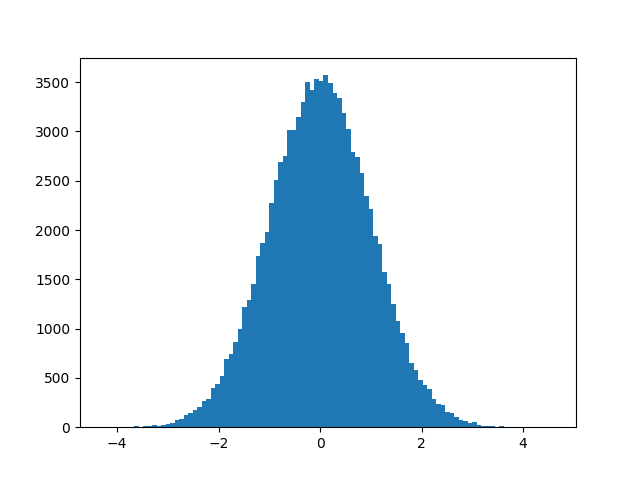

In [5]:
if __name__ == '__main__' and '__file__' not in globals():
  x = _ContinuousRandomEvent(f=_ContinuousFunction(), 
                             p=_ContinuousFunction(_gaussian(0.0, 1.0)),
                             bounds=[(-128.0, 128.0)])
  plt.hist(x.sample(100000), bins=100)